# 패턴 선택 가이드

개별 패턴을 모두 배웠다. 이번에는 "어떤 문제에 어떤 패턴을 쓸 것인가?"를 다룬다. 패턴을 아는 것과 적재적소에 쓰는 것은 다르다.

핵심은 "지금 내 문제가 왜 단순 LLM 호출로 안 되는가?"를 먼저 묻는 것이다. 그 답이 패턴을 결정한다.

- 어떤 Tool을 몇 번 써야 할지 모른다 → **ReAct**
- 입력 유형에 따라 처리가 달라야 한다 → **Router**
- 생성 품질이 불안정하다 → **Reflection**
- 명확한 품질 기준이 있다 → **Evaluator-Optimizer**
- 작업이 여러 단계를 순서대로 밟아야 한다 → **Plan-and-Execute**
- 독립적인 작업을 빠르게 처리해야 한다 → **Parallelization**
- 되돌리기 어려운 작업이 포함된다 → **Human-in-the-Loop**
- 전문 분야가 나뉘고 협업이 필요하다 → **Multi-Agent** 

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## 전체 패턴 요약

| 패턴 | 핵심 아이디어 | 제어 방식 | 적합한 경우 |
|------|-------------|----------|------------|
| 단순 LLM Chain | 프롬프트 → 응답 | 없음 (1회 호출) | Tool이나 검색 없이 답할 수 있을 때 |
| 단순 RAG | 검색 → 응답 | 고정 파이프라인 (검색→생성) | 문서 검색이 필요하지만 Agent가 검색 전략을 동적으로 바꿀 필요는 없을 때 |
| ReAct | Think → Act → Observe 루프 | LLM이 Tool 선택 | 어떤 Tool을 몇 번 쓸지 모를 때 |
| Router | 입력 분류 → 경로 분기 | 개발자가 분기 설계 | 입력 유형별 다른 처리 |
| Reflection | 생성 → 자기 검토 → 개선 | LLM이 자기 평가 | 품질이 불안정한 생성 태스크 |
| Evaluator-Optimizer | 정량 루브릭 기반 평가 → 개선 | 루브릭이 판단 | 명확한 품질 기준이 있을 때 |
| Plan-and-Execute | 계획 → 단계별 실행 → Re-plan | 계획이 흐름 결정 | 여러 단계를 순서대로 밟는 복잡한 태스크 |
| Parallelization | 독립 작업 동시 실행 | 개발자가 분기 | 독립적 작업 여러 개를 빠르게 |
| Human-in-the-Loop | 중요 지점에서 사람 승인 | 사람이 개입 | 되돌리기 어려운 작업 |
| Multi-Agent (Supervisor) | 관리자가 전문 Agent에 분배 | Supervisor가 조율 | 전문 분야가 다른 여러 Agent |
| Multi-Agent (Swarm) | Agent 간 자율 handoff | Agent가 자율 전환 | 대화 흐름에 따라 담당자 변경 |

## 패턴 조합

실무에서는 패턴 하나만 쓰는 경우가 드물다. 대부분 여러 패턴을 조합해서 시스템을 구성한다.

자주 쓰이는 조합:

| 조합 | 예시 |
|------|------|
| RAG + ReAct (Agentic RAG) | 검색 결과가 부족하면 쿼리를 바꿔 재검색하는 등 동적 검색 |
| Router + ReAct | 문의 유형 분류 → Tool이 필요한 경우만 ReAct로 처리 |
| Plan-and-Execute + ReAct | 계획 수립 후 각 단계를 ReAct Agent로 실행 |
| Supervisor + Reflection | 전문 Agent 결과를 Supervisor가 검토 후 재작업 지시 |
| ReAct + Human-in-the-Loop | Agent가 위험한 Tool을 호출하기 전에 사람에게 확인 |
| Router + Parallelization | 입력 분류 후 여러 분석을 병렬 실행 |

핵심은 **패턴을 레고 블록처럼** 생각하는 것이다. 각 패턴은 독립적인 구성 요소이고, LangGraph의 서브그래프(그래프 안에 또 다른 그래프를 넣는 것) 기능으로 자연스럽게 조합할 수 있다.

### 조합 예시: Router + Parallelization

입력을 분류한 뒤, "비교 분석" 요청이면 여러 항목을 병렬로 분석하고 결과를 종합한다.

In [ ]:
import operator
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Send

llm = ChatOpenAI(model="gpt-4o-mini")


# --- State ---
class State(TypedDict):
    messages: Annotated[list, add_messages]
    category: str           # Router가 분류한 카테고리
    items: list[str]        # 병렬 분석 대상
    results: Annotated[list[str], operator.add]      # 병렬 분석 결과


class AnalyzeInput(TypedDict):
    """Send로 전달되는 개별 분석 입력. State와는 별도의 타입이다."""
    item: str


# --- Router: 입력 분류 ---
def classify(state: State):
    response = llm.invoke(
        f"다음 요청을 'compare' 또는 'general' 중 하나로 분류해. 단어 하나만 답해.\n\n{state['messages'][-1].content}"
    )
    category = response.content.strip().lower()
    return {"category": category}


def route_by_category(state: State):
    if state["category"] == "compare":
        return "extract_items"
    return "general_answer"


# --- 비교 분석 경로: Parallelization ---
def extract_items(state: State):
    """비교 대상 항목을 추출한다."""
    response = llm.invoke(
        f"다음 요청에서 비교 대상 항목들을 쉼표로 나열해. 항목만 답해.\n\n{state['messages'][-1].content}"
    )
    items = [item.strip() for item in response.content.split(",")]
    return {"items": items}


def fan_out(state: State):
    """항목 수만큼 병렬 분석 노드를 생성한다."""
    return [Send("analyze", {"item": item}) for item in state["items"]]


def analyze(state: AnalyzeInput):
    """개별 항목을 분석한다. Send가 넘긴 AnalyzeInput을 받는다."""
    item = state["item"]
    response = llm.invoke(f"{item}의 주요 특징을 2줄로 요약해.")
    return {"results": [f"**{item}**: {response.content}"]}


def summarize(state: State):
    """병렬 분석 결과를 종합한다."""
    joined = "\n".join(state["results"])
    response = llm.invoke(f"아래 분석 결과를 비교 요약해.\n\n{joined}")
    return {"messages": [response]}


# --- 일반 경로 ---
def general_answer(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


# --- 그래프 구성 ---
builder = StateGraph(State)

builder.add_node("classify", classify)
builder.add_node("extract_items", extract_items)
builder.add_node("analyze", analyze)
builder.add_node("summarize", summarize)
builder.add_node("general_answer", general_answer)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_by_category, ["extract_items", "general_answer"])
builder.add_conditional_edges("extract_items", fan_out, ["analyze"])
builder.add_edge("analyze", "summarize")
builder.add_edge("summarize", END)
builder.add_edge("general_answer", END)

graph = builder.compile()

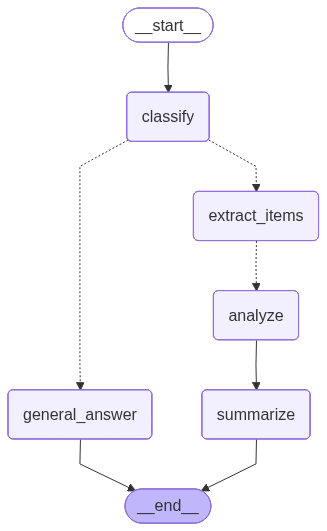

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
from langchain_core.messages import HumanMessage

# 비교 요청 → Router가 "compare"로 분류 → 병렬 분석
result = graph.invoke({
    "messages": [HumanMessage(content="Python, JavaScript, Go를 비교 분석해줘")]
})

print(result["messages"][-1].content)

**비교 요약**

1. **문법 및 생산성**:
   - **Python**: 간결하고 읽기 쉬운 문법으로 개발 생산성을 높임.
   - **JavaScript**: 객체 기반이지만, 설명된 내용에서 문법의 간결성에 대한 언급은 없음.
   - **Go**: 간결하고 효율적인 문법을 제공하여 코드를 쉽게 작성할 수 있음.

2. **주요 용도**:
   - **Python**: 데이터 분석, 웹 개발 등 다방면에서 활용됨.
   - **JavaScript**: 주로 웹 브라우저에서 동적인 웹 페이지 생성을 위해 사용됨.
   - **Go**: 일반적으로 효율성과 성능을 중시하는 백엔드 개발에 적합할 것으로 보임.

3. **프로그래밍 모델 및 기능**:
   - **Python**: 객체 지향 프로그래밍 지원.
   - **JavaScript**: 비동기 처리 및 이벤트 중심 프로그래밍 지원, 사용자 경험 향상에 중점.
   - **Go**: 고루틴을 통한 동시성 프로그래밍 지원, 강타입 시스템과 자동 메모리 관리로 안정성과 성능을 강조.

4. **플랫폼**:
   - **Python**: 인터프리터 언어로 플랫폼 독립적.
   - **JavaScript**: 주로 웹에서 사용되며, 플랫폼 의존성이 낮음.
   - **Go**: 플랫폼 독립성을 갖는 언어이나, 특정 환경에서 최적화된 성능을 제공할 수 있음. 

종합적으로, Python은 다양한 분야에 적합한 생산성 높은 언어, JavaScript는 동적 웹 개발에 특화된 언어, Go는 성능과 안정성을 강조한 언어로 각각의 강점을 지니고 있습니다.


## 패턴 선택 실습

아래 시나리오를 읽고 어떤 패턴(또는 조합)이 적합한지 생각해 보자.

In [ ]:
# 시나리오 1: 고객이 채팅으로 환불을 요청한다. 환불 정책 문서를 검색하고,
# 조건을 확인한 뒤, 실제 환불 처리 전에 담당자 승인을 받아야 한다.
# → 패턴 조합: ???

# 시나리오 2: 사용자가 자유롭게 질문하면, 질문 유형(일반/기술/영업)에 따라
# 각각 다른 전문 프롬프트로 답변해야 한다.
# → 패턴: ???

# 시나리오 3: 블로그 글을 작성하는데, SEO 키워드 포함, 톤 일관성,
# 최소 글자 수 등 명확한 기준을 충족해야 한다.
# → 패턴: ???

# 시나리오 4: 경쟁사 5곳의 제품 정보를 각각 조사하고,
# 비교표를 만든 뒤, 종합 보고서를 작성해야 한다.
# → 패턴 조합: ???

<details>
<summary>정답 보기</summary>

1. RAG + ReAct + Human-in-the-Loop: 환불 정책 검색(RAG) → 조건 확인 및 환불 처리(ReAct로 Tool 호출) → 처리 전 승인(HITL)
2. Router: 의도 분류 → 전문 프롬프트 분기
3. Evaluator-Optimizer: SEO/톤/길이 루브릭으로 평가 → 미달 시 재생성
4. Plan-and-Execute + Parallelization + ReAct: 계획 수립 → 5곳 병렬 조사(각 조사에서 ReAct로 검색 Tool 활용) → 비교표 → 보고서

</details>

## 비용과 지연 시간

패턴 선택 시 성능만 볼 게 아니라 비용과 지연도 고려해야 한다.

| 패턴 | LLM 호출 수 | 비용 특성 | 지연 시간 |
|------|------------|----------|----------|
| 단순 Chain | 1회 | 최저 | 최단 |
| ReAct | 2~10+회 | Tool 수에 비례 | 중간~긴 |
| Reflection | 2~6회 | 반복 수에 비례 | 중간 |
| Plan-and-Execute | 3~15+회 | 단계 수에 비례 | 긴 |
| Multi-Agent | 5~20+회 | Agent 수 × 호출 수 | 가장 긴 |
| Parallelization | N회 (동시) | 병렬 수에 비례 | 순차보다 짧음 |

패턴이 복잡할수록 비용과 지연이 늘어난다. **항상 가장 단순한 패턴부터 시도하고, 부족할 때만 복잡한 패턴으로 올려야 한다.**